In [118]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import numpy as np

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [103]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [104]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [105]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(100)
large_buy_orders.head(5)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320


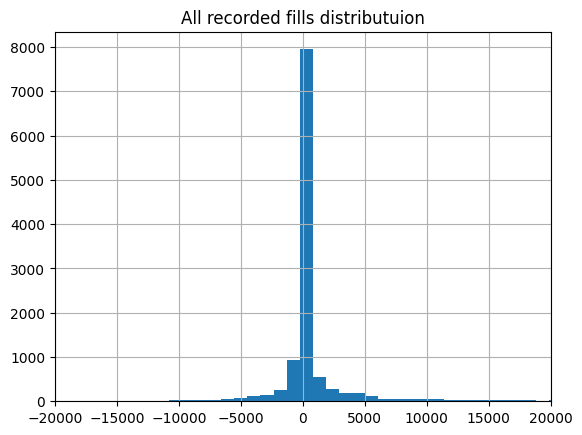

count     11582.000000
mean        458.266966
std        5172.764186
min     -270000.000000
25%         -45.000000
50%          11.000000
75%         240.000000
max      153143.000000
Name: volume, dtype: float64

In [106]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [107]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [108]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [109]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32065,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [110]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
22,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
97,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
1,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
0,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
82,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.20,8.78,8.490


In [111]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
2,2026-03-25 15:22:54+00:00,SR330CP6A,18631,11,330,2026-03-25 15:23:04+00:00,11.09,11.70,11.395
3,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355
4,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040


In [130]:
horizons = [1, 2, 3, 4, 5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
#horizons = np.linspace(1, 10080, 20, dtype=int)
print(horizons)
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

[1, 2, 3, 4, 5, 30, 60, 120, 480, 720, 1440, 4320, 10080]


C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\4167491141.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'best_ask_{h}'] = merged['best_ask_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\4167491141.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'best_bid_{h}'] = merged['best_bid_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\4167491141.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_price_return_9549,best_ask_2,best_bid_2,mid_2,best_ask_3,best_bid_3,mid_3,best_ask_4,best_bid_4,mid_4
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,NaN,NaN,NaN,NaN,9.30,8.31,8.805,9.30,8.31,8.805
1,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340,2026-04-01 11:46:14+00:00,...,NaN,12.68,12.00,12.340,12.68,12.00,12.340,NaN,NaN,NaN
2,2026-03-25 15:22:54+00:00,SR330CP6A,18631,11,330,2026-03-25 15:23:04+00:00,11.09,11.70,11.395,2026-04-01 15:23:04+00:00,...,0.336551,NaN,NaN,NaN,12.28,11.11,11.695,12.28,11.11,11.695
3,2026-03-26 15:34:32+00:00,SR320CP6A,26606,4,320,2026-03-26 15:34:40+00:00,4.00,4.71,4.355,2026-04-02 15:34:40+00:00,...,-0.032147,4.71,4.32,4.515,4.71,4.32,4.515,4.71,4.32,4.515
4,2026-03-27 09:21:45+00:00,SR270CD6,32473,47,270,2026-03-27 09:22:28+00:00,46.37,47.71,47.040,2026-04-03 09:22:28+00:00,...,0.024022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

C:\Users\bakae\AppData\Local\Temp\ipykernel_14028\1456302144.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']


In [132]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}'].dropna()

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 1, count = 50
h = 2, count = 55
h = 3, count = 72
h = 4, count = 74
h = 5, count = 74
h = 30, count = 91
h = 60, count = 94
h = 120, count = 94
h = 480, count = 75
h = 720, count = 66
h = 1440, count = 70
h = 4320, count = 68
h = 10080, count = 71


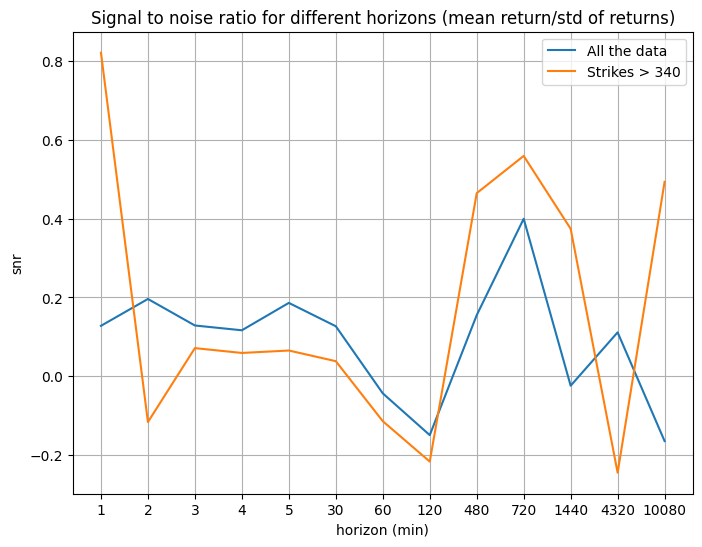

In [133]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()

In [134]:
stats = pd.DataFrame({
    'mean': [df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std': [df[f'mid_price_return_{h}'].std() for h in horizons],
    'count': [df[f'mid_price_return_{h}'].notna().sum() for h in horizons],
    'mean_otm': [filtered_df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std_otm': [filtered_df[f'mid_price_return_{h}'].std() for h in horizons],
    'count_otm': [filtered_df[f'mid_price_return_{h}'].notna().sum() for h in horizons]
}, index=horizons)
stats

,mean,std,count,mean_otm,std_otm,count_otm
1,0.002926,0.022869,50,0.005642,0.006676,6
2,0.004638,0.023642,55,0.005059,0.005107,7
3,0.004523,0.035122,72,0.002132,0.003835,7
4,0.005424,0.046509,74,-0.000582,0.008246,7
5,0.008569,0.046017,74,0.000386,0.008711,7
30,0.010873,0.085687,91,-0.003072,0.012510,8
60,-0.004217,0.096690,94,-0.007519,0.032270,8
120,-0.013962,0.093218,94,-0.002898,0.038876,8
480,0.206478,1.331966,75,0.019774,0.042934,7
720,1.241327,3.103740,66,0.032078,0.040255,5


In [157]:
from scipy import stats

rows = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

    rows.append({
        'horizon': h,
        't_stat': t_stat,
        'p_value': p_value
    })

t_test_res = pd.DataFrame(rows).set_index('horizon').T
t_test_res

horizon,1,2,3,4,5,30,60,120,480,720,1440,4320,10080
t_stat,0.904651,1.454970,1.092817,1.003228,1.601857,1.210512,-0.422882,-1.452096,1.342492,3.249173,-0.202883,0.918238,-1.389539
p_value,0.370077,0.151466,0.278168,0.319065,0.113506,0.229252,0.673357,0.149840,0.183540,0.001834,0.839824,0.361788,0.169073
